<a href="https://colab.research.google.com/github/nourswaid/ML-A_Z-/blob/main/Reinforcement%20Learning/Upper%20Confidence%20Bound%20(UCB)/upper_confidence_bound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upper Confidence Bound (UCB)



Note :the data here is a simulation, the algorithm normally follow a dynamic (real time ) process to see who click the add or not and take that data so data here is a simulation for that scnario.






## Importing the libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Importing the dataset

In [14]:
df=pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing UCB

In [29]:
N=1000
d=10
add_selected=[]
numbers_of_selection=[0]*d
sums_of_rewards=[0]*d
total_rewards=0

for n in range(0, N):

    ad = 0
    max_upper_round = 0

    for i in range(0, d):
        if numbers_of_selection[i] > 0:
            average_reward = sums_of_rewards[i] / numbers_of_selection[i]
            delta_i = math.sqrt(
                3/2 * math.log(n + 1) / numbers_of_selection[i])
            upper_bound = average_reward + delta_i
        else:
            upper_bound = 1e400
        if upper_bound > max_upper_round:
            max_upper_round = upper_bound
            ad = i

    add_selected.append(ad)
    numbers_of_selection[ad] += 1
    reward = df.values[n, ad]
    sums_of_rewards[ad] += reward
    total_rewards += reward

## Visualising the results

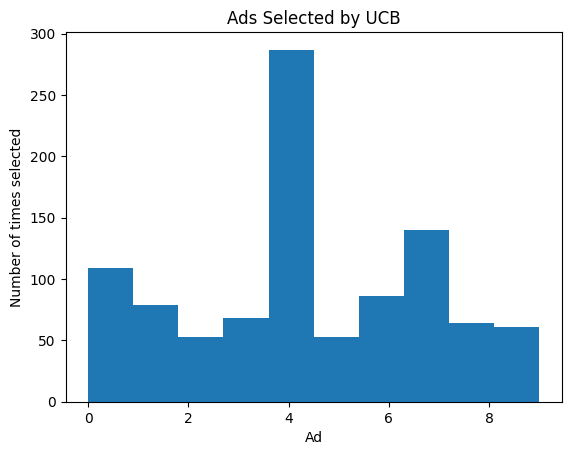

In [30]:
import matplotlib.pyplot as plt

plt.hist(add_selected)
plt.xlabel("Ad")
plt.ylabel("Number of times selected")
plt.title("Ads Selected by UCB")
plt.show()